# K-Nearest Neighbors — From Scratch

KNN is the simplest possible ML algorithm: memorize all training data,
and at inference time find the k closest points and vote.

Despite its simplicity, it demonstrates core ideas that appear everywhere:
- Distance geometry and feature scaling
- The bias-variance tradeoff via k
- The curse of dimensionality


In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline

from knn import KNNClassifier, KNNRegressor
np.random.seed(42)


## 1. The Core Algorithm

For a query point x:
1. Compute distance to every training point: `O(N × D)` per query
2. Sort by distance, take k nearest
3. Return majority vote (classification) or mean (regression)

**Why feature scaling is critical:**
If feature 1 ranges 0–1 and feature 2 ranges 0–1000, distance is
dominated by feature 2. StandardScaler fixes this.


In [2]:
# Show what happens without scaling
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42)
# Artificially scale one feature
X_bad = X.copy()
X_bad[:, 1] *= 100

X_tr, X_te, y_tr, y_te = train_test_split(X_bad, y, test_size=0.2, random_state=42)

knn_unscaled = KNNClassifier(k=5).fit(X_tr, y_tr)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
knn_scaled = KNNClassifier(k=5).fit(X_tr_s, y_tr)

print(f"Accuracy WITHOUT scaling: {knn_unscaled.score(X_te, y_te):.3f}")
print(f"Accuracy WITH scaling:    {knn_scaled.score(X_te_s, y_te):.3f}")


Accuracy WITHOUT scaling: 0.670
Accuracy WITH scaling:    0.930


## 2. Decision Boundaries — Effect of k

Low k = complex boundary (low bias, high variance) → overfits
High k = smooth boundary (high bias, low variance) → underfits


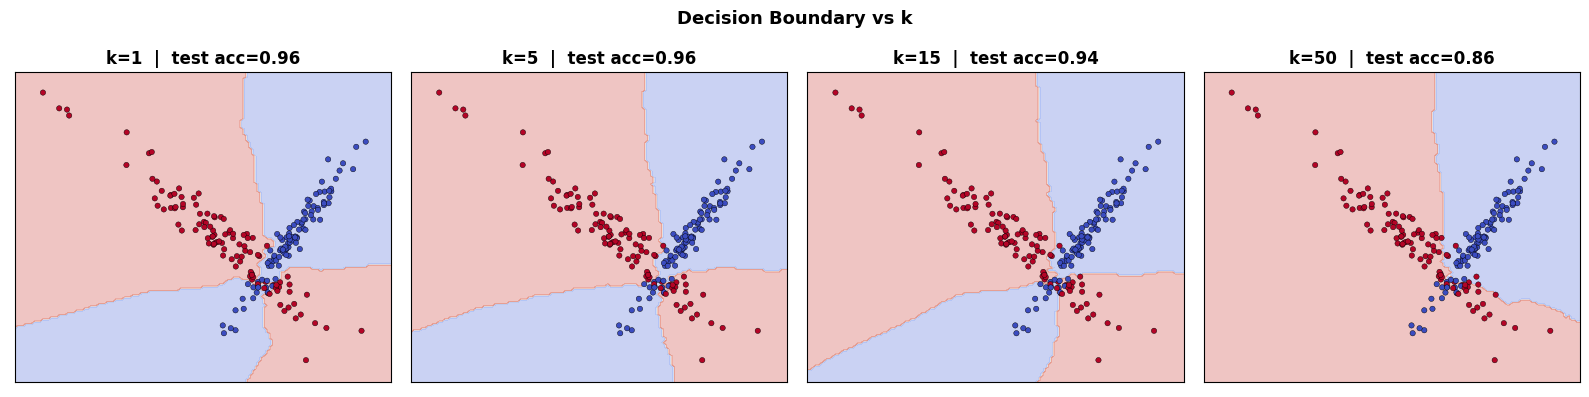

In [3]:
X2, y2 = make_classification(n_samples=300, n_features=2, n_redundant=0,
                              n_informative=2, n_clusters_per_class=1, random_state=1)
scaler2 = StandardScaler()
X2s = scaler2.fit_transform(X2)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X2s, y2, test_size=0.3, random_state=42)

# Grid for decision boundary
h = 0.05
x_min, x_max = X2s[:, 0].min() - 0.5, X2s[:, 0].max() + 0.5
y_min, y_max = X2s[:, 1].min() - 0.5, X2s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes, [1, 5, 15, 50]):
    knn = KNNClassifier(k=k).fit(X_tr2, y_tr2)
    Z = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_tr2[:, 0], X_tr2[:, 1], c=y_tr2, cmap='coolwarm', s=15, edgecolors='k', linewidths=0.3)
    acc = knn.score(X_te2, y_te2)
    ax.set_title(f'k={k}  |  test acc={acc:.2f}', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Decision Boundary vs k', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 3. Choosing k — Validation Curve

The right k balances bias and variance. We sweep k and plot train/val accuracy.


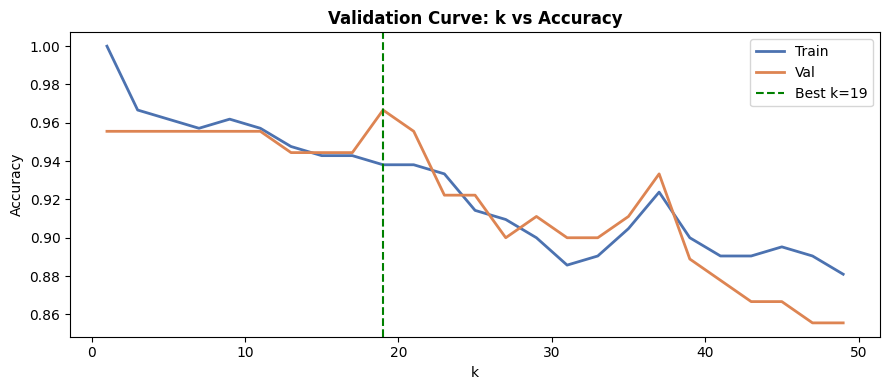

Best k=19, val acc=0.967


In [4]:
k_range = range(1, 51, 2)
train_accs, val_accs = [], []

for k in k_range:
    knn = KNNClassifier(k=k).fit(X_tr2, y_tr2)
    train_accs.append(knn.score(X_tr2, y_tr2))
    val_accs.append(knn.score(X_te2, y_te2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), train_accs, label='Train', color='#4C72B0', linewidth=2)
ax.plot(list(k_range), val_accs,   label='Val',   color='#DD8452', linewidth=2)
ax.axvline(list(k_range)[np.argmax(val_accs)], color='green', linestyle='--',
           label=f'Best k={list(k_range)[np.argmax(val_accs)]}')
ax.set_xlabel('k'); ax.set_ylabel('Accuracy')
ax.set_title('Validation Curve: k vs Accuracy', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Best k={list(k_range)[np.argmax(val_accs)]}, val acc={max(val_accs):.3f}")


## 4. Validation Against sklearn

In [5]:
from sklearn.datasets import load_iris
X_iris, y_iris = load_iris(return_X_y=True)
mask = y_iris < 2
X_i, y_i = X_iris[mask], y_iris[mask]
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_i, y_i, test_size=0.2, random_state=0)
sc = StandardScaler()
X_tr_i = sc.fit_transform(X_tr_i); X_te_i = sc.transform(X_te_i)

my_knn = KNNClassifier(k=5).fit(X_tr_i, y_tr_i)
sk_knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr_i, y_tr_i)

print("Predictions match sklearn:", np.array_equal(my_knn.predict(X_te_i), sk_knn.predict(X_te_i)))
print(f"My accuracy:  {my_knn.score(X_te_i, y_te_i):.4f}")
print(f"SK accuracy:  {sk_knn.score(X_te_i, y_te_i):.4f}")


Predictions match sklearn: True
My accuracy:  1.0000
SK accuracy:  1.0000


## 5. The Curse of Dimensionality

As dimensions increase, all points become roughly equidistant.
KNN breaks down because "nearest" loses meaning.


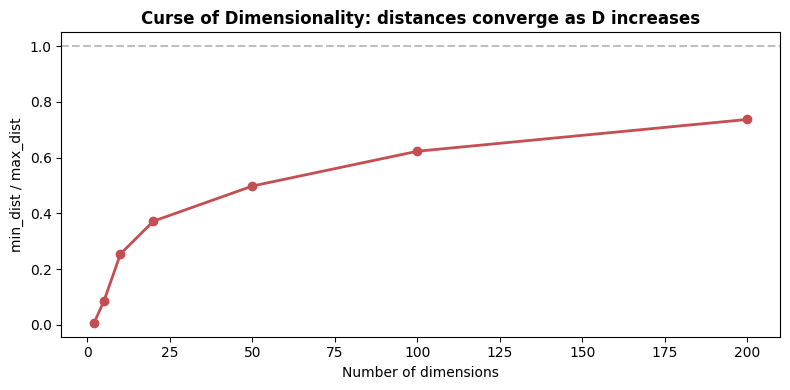

As ratio → 1, all points are the same distance → KNN is meaningless


In [6]:
dims = [2, 5, 10, 20, 50, 100, 200]
mean_ratios = []

for d in dims:
    pts = np.random.randn(500, d)
    query = np.zeros((1, d))
    dists = np.sqrt(((pts - query)**2).sum(axis=1))
    ratio = dists.min() / dists.max()   # close to 1 = distances are similar = KNN useless
    mean_ratios.append(ratio)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dims, mean_ratios, 'o-', color='#C44E52', linewidth=2, markersize=6)
ax.set_xlabel('Number of dimensions'); ax.set_ylabel('min_dist / max_dist')
ax.set_title('Curse of Dimensionality: distances converge as D increases', fontweight='bold')
ax.axhline(1.0, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout(); plt.show()
print("As ratio → 1, all points are the same distance → KNN is meaningless")
